## Une as duas tabelas

In [13]:
import pandas as pd

# Ler os arquivos CSV
articles_df = pd.read_csv('articles.csv')
data_extraction_df = pd.read_csv('data_extraction.csv')

outputCsv = 'merged_articles_data.csv'

# Renomear colunas para facilitar o merge
data_extraction_df = data_extraction_df.rename(columns={'article': 'title'})

# Converter colunas de data para datetime (se necessário)
articles_df['year'] = pd.to_numeric(articles_df['year'], errors='coerce')
data_extraction_df['Ano'] = pd.to_numeric(data_extraction_df['Ano'], errors='coerce')

# Fazer o merge dos dataframes
merged_df = pd.merge(
    articles_df,  # Colunas que queremos do articles.csv
    data_extraction_df,
    on='title',
    how='outer'
)

# Preencher anos faltantes: usar o ano do data_extraction quando não houver no articles
merged_df['year'] = merged_df['year'].fillna(merged_df['Ano'])

# Remover a coluna Ano auxiliar
merged_df = merged_df.drop(columns=['Ano'])

# Renomear coluna year para ano para manter consistência
merged_df = merged_df.rename(columns={'year': 'ano'})

# Reordenar colunas (opcional)
cols = ['title', 'ano'] + [col for col in merged_df.columns if col not in ['title', 'ano']]
merged_df = merged_df[cols]

# Salvar o resultado em um novo arquivo CSV
merged_df.to_csv(outputCsv, index=False)

print("Arquivo criado com sucesso!")
print(f"Total de registros: {len(merged_df)}")

Arquivo criado com sucesso!
Total de registros: 1515


# Corrige termos

In [14]:
import pandas as pd

inputCsv = 'merged_articles_data.csv'
outputCsv = 'transformed_data.csv'

# Dicionário de traduções
translation_dict = {
    # Tecnologias de Display
    'Embutido': 'Embedded',
    'Projetor superior': 'Front-Projected',
    'Projetor inferior': 'Rear-Projected',

    # Tecnologias de Input
    'Caneta': 'Pen',
    'Ondas sonoras': 'Sound-Based',
    'Sensor infravermelho': 'Sensor-Assisted-Vision-Based',
    'Tokens tangíveis': 'Tangible-Tokens',
    'Toque': 'Electrical-Based',
    'Visão computacional': 'Vision-Based',

    # Critérios de seleção
    'Incomplete works, posters, summaries': 'Incomplete works, posters, summaries, etc',
    'Interfaces with only mouse/keyboard interaction': 'Interfaces without direct interaction',
    'The digital tabletop interface was not tangible': 'Study was not about digital tabletops',
}

def translate_terms(text):
    if pd.isna(text):
        return text
    for pt, en in translation_dict.items():
        text = text.replace(pt, en)
    return text

# Carregar os dados (substitua pelo seu arquivo real)
df = pd.read_csv(inputCsv)

# Aplicar traduções nas colunas relevantes
df['Tecnologia do display'] = df['Tecnologia do display'].apply(translate_terms)
df['Tecnologia do input'] = df['Tecnologia do input'].apply(translate_terms)
df['selection_criteria'] = df['selection_criteria'].apply(translate_terms)

# Salvar o resultado (substitua pelo nome desejado)
df.to_csv(outputCsv, index=False)

print("Transformação concluída! Resultado salvo em " + outputCsv)
print("\nAmostra dos dados transformados:")
print(df.head())

Transformação concluída! Resultado salvo em transformed_data.csv

Amostra dos dados transformados:
                                               title     ano  bibtex_key  \
0  "All in the Same Boat": Tradeoffs of Voice Ass...  2020.0         NaN   
1  "Callout Bubble Saved My Life": Workspace Awar...  2015.0         NaN   
2  "Dinner Party" sociable interfaces in a tablet...  2011.0         NaN   
3  "Local Remote" Collaboration: Applying Remote ...  2015.0         NaN   
4                   1.24 - Augmented Reality and GIS  2018.0         NaN   

                                              author journal  \
0  Storer, Kevin M. and Judge, Tejinder K. and Br...     NaN   
1  Chang, Y.-L. Betty and Fong, Cresencia and Tse...     NaN   
2  Nam, Hye Yeon and DiSalvo, Carl and Do, Ellen ...     NaN   
3  Scott, Stacey D. and Graham, T.C. Nicholas and...     NaN   
4                                        Nick Hedley     NaN   

                source    pages volume  \
0  ACM Digital Li

# Gráficos

## Artigos aceitos por ano

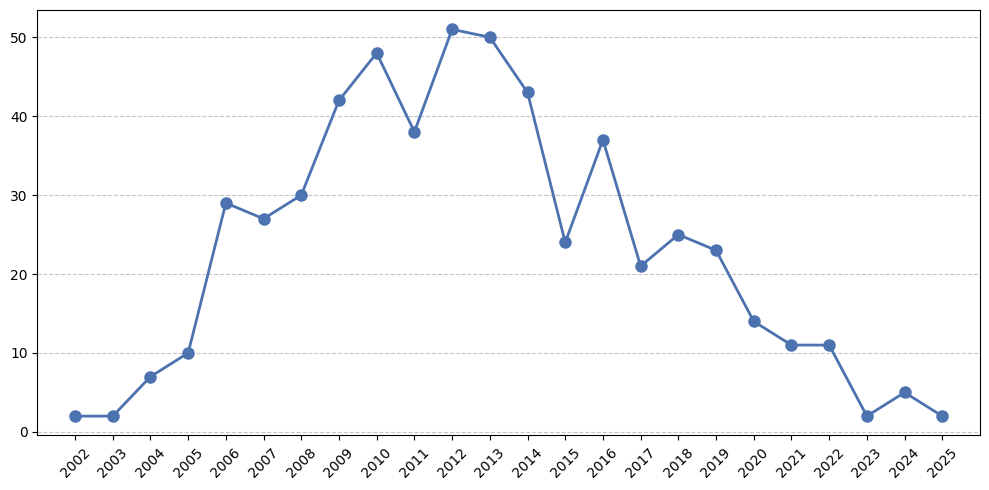

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados
articles_df = pd.read_csv('articles.csv')

# Filtrar apenas artigos "Accepted" e contar por ano
accepted_per_year = articles_df[articles_df['status'] == 'Accepted']['year'].value_counts().sort_index()

# Configurar o gráfico
plt.figure(figsize=(10, 5))
accepted_per_year.plot(
    marker='o',
    linestyle='-',
    color='#4C72B0',
    linewidth=2,
    markersize=8
)

# Adicionar rótulos e título
plt.title('', fontsize=14, pad=20)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar eixos para mostrar apenas anos com dados
plt.xticks(accepted_per_year.index, rotation=45)
plt.xlim(accepted_per_year.index.min() - 1, accepted_per_year.index.max() + 1)

plt.tight_layout()
plt.savefig('accepted_per_year.png', dpi=300)
plt.show()

## Razões de aceite/rejeite

IndexError: list index out of range

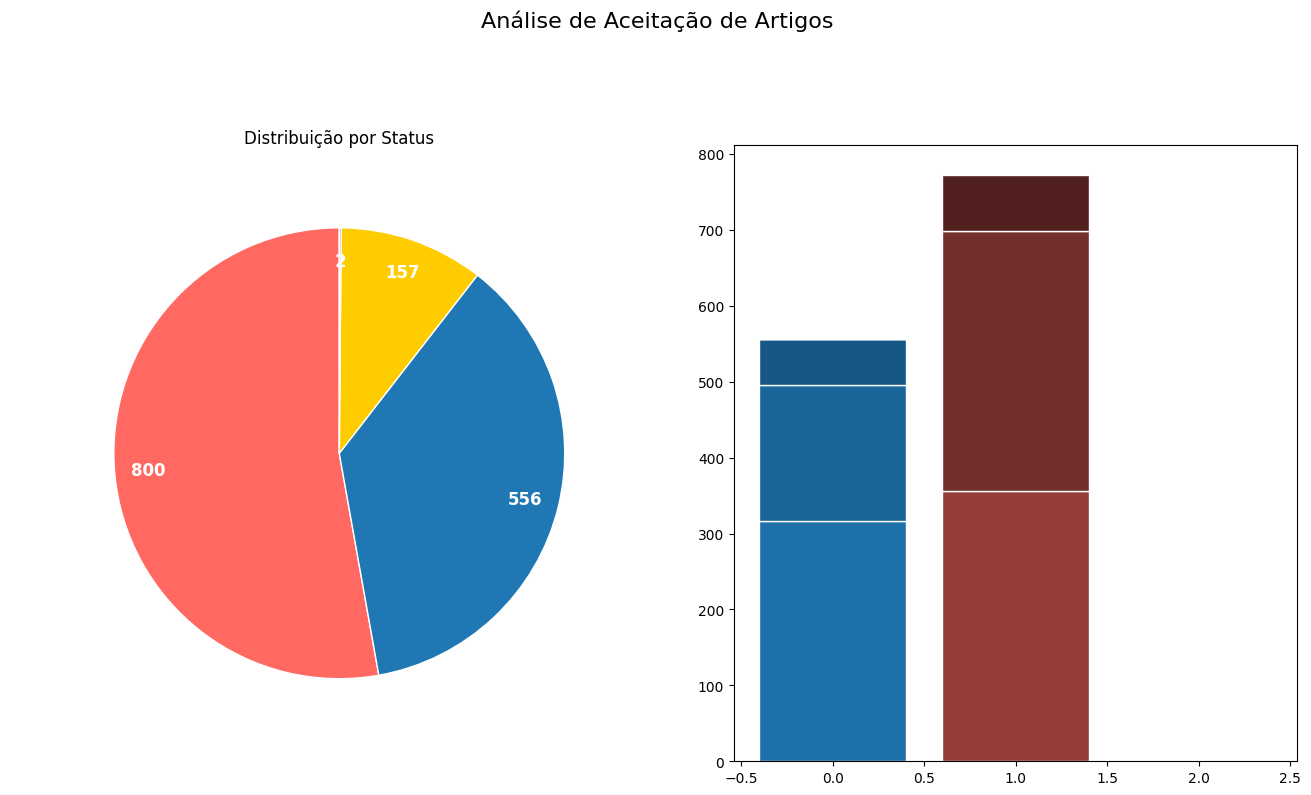

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Carregar os dados
articles_df = pd.read_csv('articles.csv')

# 1. Contar status
status_counts = articles_df['status'].value_counts()

# 2. Análise dos critérios de seleção para subdivisão
criteria_analysis = defaultdict(dict)

for status in ['Accepted', 'Rejected', 'Duplicated']:
    subset = articles_df[articles_df['status'] == status]
    criteria_counts = subset['selection_criteria'].value_counts()
    for criteria, count in criteria_counts.items():
        if pd.notna(criteria):  # Ignorar valores NaN
            criteria_analysis[status][criteria] = count

# Criar DataFrame a partir da análise
criteria_df = pd.DataFrame.from_dict(criteria_analysis, orient='index').fillna(0)

# 3. Criar figura com subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Análise de Aceitação de Artigos', fontsize=16, y=1.05)

# Função para obter a cor do status
def get_status_color(status):
    return {
        'Accepted': '#1f77b4',  # Azul
        'Rejected': '#ff6961',  # Vermelho
        'Duplicated': '#ffcc00'  # Amarelo
    }.get(status, '#999999')  # Cinza para outros status

# Gráfico de pizza principal (Status)
wedges, texts, autotexts = ax1.pie(
    status_counts,
    labels=status_counts.index,
    colors=[get_status_color(s) for s in status_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    autopct=lambda p: f'{int(p * sum(status_counts)/100)}',
    pctdistance=0.85,
    textprops={'fontsize': 12, 'color': 'white', 'weight': 'bold'}
)

ax1.set_title('Distribuição por Status', pad=20)

# Tons de cinza base para os critérios (de claro para escuro)
base_greys = ['#f0f0f0', '#d9d9d9', '#bdbdbd', '#969696', '#737373', '#525252']

# Gerar cores específicas para cada status
status_colors = {}
for status in criteria_df.index:
    status_colors[status] = []
    for grey in base_greys[:len(criteria_df.columns)]:
        # Mistura a cor do status com o tom de cinza
        status_r = int(get_status_color(status)[1:3], 16)
        status_g = int(get_status_color(status)[3:5], 16)
        status_b = int(get_status_color(status)[5:7], 16)

        grey_r = int(grey[1:3], 16)
        grey_g = int(grey[3:5], 16)
        grey_b = int(grey[5:7], 16)

        mixed_r = min(255, int(status_r * grey_r / 255))
        mixed_g = min(255, int(status_g * grey_g / 255))
        mixed_b = min(255, int(status_b * grey_b / 255))

        mixed_color = f'#{mixed_r:02x}{mixed_g:02x}{mixed_b:02x}'
        status_colors[status].append(mixed_color)

# Plotar gráfico de barras empilhadas com cores adaptadas
x = np.arange(len(criteria_df.index))  # Posições das barras
width = 0.8  # Largura das barras
bottom = np.zeros(len(criteria_df.index))  # Inicializar valores base

# Para cada critério (coluna)
for j, criteria in enumerate(criteria_df.columns):
    heights = criteria_df[criteria].values

    # Para cada status (linha)
    for i, status in enumerate(criteria_df.index):
        ax2.bar(
            x[i],
            heights[i],
            width,
            bottom=bottom[i],
            color=status_colors[status][j],
            edgecolor='white',
            label=criteria if i == 0 else ""  # Label apenas para primeira barra
        )

    bottom += heights  # Atualizar base para próximo critério

# Configurar eixo x
ax2.set_xticks(x)
ax2.set_xticklabels(criteria_df.index)
ax2.set_title('Motivos por Status', pad=20)
ax2.set_ylabel('Quantidade de Artigos')
ax2.set_xlabel('Status')
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Criar legendas personalizadas para evitar duplicatas
handles, labels = ax2.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax2.legend(unique_labels.values(), unique_labels.keys(),
           title='Critérios', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout
plt.tight_layout()
plt.savefig('enhanced_acceptance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Tecnologias de Input por ano

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar e preparar os dados
data_extraction_df = pd.read_csv('data_extraction.csv')

# Expandir múltiplas tecnologias de input (separadas por vírgula)
input_tech = data_extraction_df['Tecnologia do input'].str.get_dummies(sep=', ')

# Combinar com o ano e agregar
tech_by_year = pd.concat([data_extraction_df['Ano'], input_tech], axis=1)
tech_by_year = tech_by_year.groupby('Ano').sum()

# Configurar cores
colors = plt.cm.Paired(range(len(tech_by_year.columns)))

# Plotar
plt.figure(figsize=(12, 6))
tech_by_year.plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Ajustes estéticos
plt.title('Evolução das Tecnologias de Input por Ano', fontsize=14, pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Contagem de Artigos', fontsize=12)
plt.legend(
    title='Tecnologia',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('input_tech_by_year.png', dpi=300)
plt.show()